# 07 — Client activity recency ranking

Most recent visit-or-payment activity per client (CTE + `GREATEST`/`COALESCE`), ranked oldest-to-return-to first with `RANK()` — the 50 clients most overdue for a re-engagement outreach. Mirrors `docs/Client_Querires.md` §1.4.

Contains client names — for local exploration only, not for the README highlights.

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_ANALYST_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
query = """
WITH last_activity AS (
  SELECT
    u.id AS client_id,
    u.name,
    u.surname,
    GREATEST(
      COALESCE(MAX(v.created_at), '1970-01-01'),
      COALESCE(MAX(p.payment_date), '1970-01-01')
    ) AS last_seen_at
  FROM users u
  LEFT JOIN visits v ON v.client_id = u.id
  LEFT JOIN client_payments p ON p.user_id = u.id AND p.visit_paid = 1
  WHERE u.role_id = 6
  GROUP BY u.id, u.name, u.surname
)
SELECT
  client_id, name, surname, last_seen_at,
  DATEDIFF(CURRENT_DATE, last_seen_at) AS days_since_last_seen,
  RANK() OVER (ORDER BY last_seen_at ASC) AS inactivity_rank
FROM last_activity
ORDER BY last_seen_at ASC
LIMIT 50;
"""

df = pd.read_sql(query, engine, parse_dates=["last_seen_at"])
print(df)

    client_id        name       surname last_seen_at  days_since_last_seen  \
0          30     Despina         Vandi   1970-01-01                 20654   
1           9      Taylor         Swift   1970-01-01                 20654   
2          11     Beyoncé       Knowles   1970-01-01                 20654   
3         148   testLocal          csrf   1970-01-01                 20654   
4          23        Eros    Ramazzotti   1970-01-01                 20654   
5          25    Zinedine        Zidane   1970-01-01                 20654   
6          26       Irina         Rimes   1970-01-01                 20654   
7          36     Tiziano         Ferro   1970-01-01                 20654   
8          28     Enrique      Iglesias   1970-01-01                 20654   
9          29     Rosalía  Vila Tobella   1970-01-01                 20654   
10          8          Ed       Sheeran   1970-01-01                 20654   
11         31        Lili       Ivanova   1970-01-01            

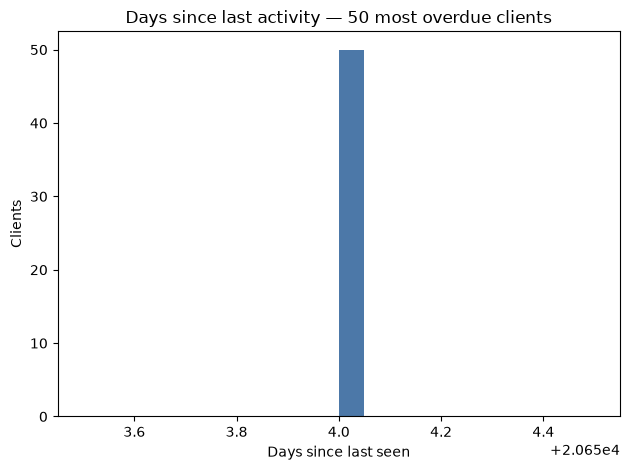

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

if df.empty:
    print("No client activity data found.")
else:
    plt.hist(df["days_since_last_seen"], bins=20, color="#4C78A8")
    plt.title("Days since last activity — 50 most overdue clients")
    plt.xlabel("Days since last seen")
    plt.ylabel("Clients")
    plt.tight_layout()
    plt.show()